# Clean EDA + Training CAMeLBERT (MSA)
Notebook نظيف بدون استخدام `__file__`، مع وضع **المسارات المطلقة التي أعطيتِني إياها**:
- `C:/Users/jorif/Downloads/nlp_data/nlp_data/train-70.csv`
- `C:/Users/jorif/Downloads/nlp_data/nlp_data/val-20.csv`
- `C:/Users/jorif/Downloads/nlp_data/nlp_data/test-10.csv`


In [1]:

# ============== 1) الاستيراد والإعدادات العامة ==============
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
from sklearn.metrics import classification_report

pd.set_option("display.max_colwidth", 200)

TRAIN_PATH = r"C:\Users\LENOVO\Downloads\NLP_Proj\Data\train-70.csv"
VAL_PATH   = r"C:\Users\LENOVO\Downloads\NLP_Proj\Data\val-20.csv"
TEST_PATH  = r"C:\Users\LENOVO\Downloads\NLP_Proj\Data\test-10.csv"

OUT_DIR = r"C:\Users\LENOVO\Downloads\NLP_Proj"
os.makedirs(OUT_DIR, exist_ok=True)


c:\Users\LENOVO\Downloads\NLP_Proj\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# ============== 2) تحميل البيانات ==============
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()


(31850, 3) (9100, 3) (4550, 3)


,text,label_name,label
0,استهل ريال مدريد حملته نحو محاولة إزاحة غريمة برشلونة عن العرش الذي تربع عليه النادي الكاتالوني في المواسم الثلاثة الأخيرة، بفوز ساحق خارج قواعده على ريال سرقسطة 6-صفر في المرحلة الثانية من الدوري...,Sports,5
1,انتقد مركز الشهاب لحقوق الإنسان قانون التظاهر السلمي، الذي سوف يناقشه مجلس الشورى خلال الأيام المقبلة . وطالب المركز بضرورة عرض القانون للحوار المجتمعي من قبل الأحزاب والقوى السياسية ومنظمات المجت...,Politics,3
2,تصوير: صلاح طاهر ما زالت الخدمات المقدمة في إدارة الطب الوقائي في عجمان، غير قادرة على تلبية التطور المتزايد الذي تشهده المنطقة، في الوقت الذي يتكدس فيه العشرات من المراجعين أمام المبنى وداخله، فا...,Medical,2
3,الشارقة: «الخليج»اختتم برنامج مجالس الشعراء الرمضاني الذي ينظمه مركز الشارقة للشعر الشعبي مساء أمس، جلساته بأمسية في بيت الشاعر سعد الخرجي في أم القيوين، دار الحوار فيها حول «مجالس الشعراء الرمضان...,Culture,0
4,دبي: «الخليج» أعلنت هيئة الصحة بدبي، أمس، مواعيد وساعات العمل في المستشفيات والمراكز الصحية التابعة لها خلال عطلة الإسراء والمعراج التي ستصادف غداً الخميس.وكلفت الهيئة في تعميم لها المديرين التنفي...,Medical,2


In [3]:
# ============== 3) فحص الجودة ==============
def quality(df, name):
    print(f"===== {name} =====")
    print("Missing:\n", df.isna().sum())
    print("Duplicates:", df.duplicated(subset=["text"]).sum())

quality(train_df, "TRAIN")
quality(val_df,   "VAL")
quality(test_df,  "TEST")


===== TRAIN =====
Missing:
 text          0
label_name    0
label         0
dtype: int64
Duplicates: 4
===== VAL =====
Missing:
 text          0
label_name    0
label         0
dtype: int64
Duplicates: 1
===== TEST =====
Missing:
 text          0
label_name    0
label         0
dtype: int64
Duplicates: 0


In [4]:

# ============== 4) تنظيف البيانات ==============
def clean(df):
    df = df.dropna(subset=["text", "label_name", "label"])
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"] != ""]
    df = df.drop_duplicates(subset=["text"])
    return df

train_c = clean(train_df)
val_c   = clean(val_df)
test_c  = clean(test_df)

print(train_c.shape, val_c.shape, test_c.shape)


(31846, 3) (9099, 3) (4550, 3)


In [5]:

# ============== 5) حفظ البيانات النظيفة ==============
# ============== 5) حفظ البيانات النظيفة ==============

train_c.to_csv(r"C:\Users\LENOVO\Downloads\NLP_Proj\Data\train_clean.csv",index=False, encoding="utf-8-sig")

val_c.to_csv(r"C:\Users\LENOVO\Downloads\NLP_Proj\Data\validation_clean.csv",index=False, encoding="utf-8-sig")

test_c.to_csv(r"C:\Users\LENOVO\Downloads\NLP_Proj\Data\test_clean.csv",index=False, encoding="utf-8-sig")

print("✔ Saved cleaned CSV files.")



✔ Saved cleaned CSV files.


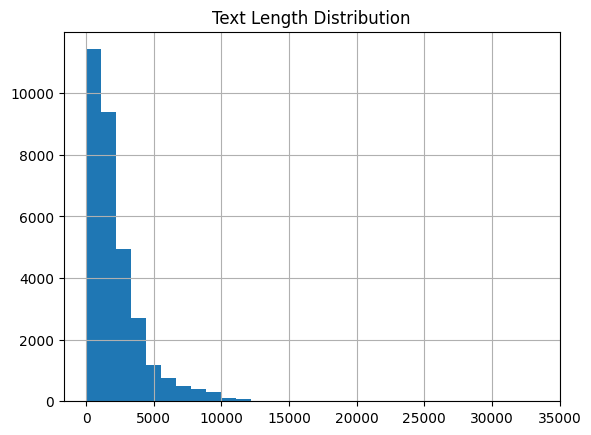

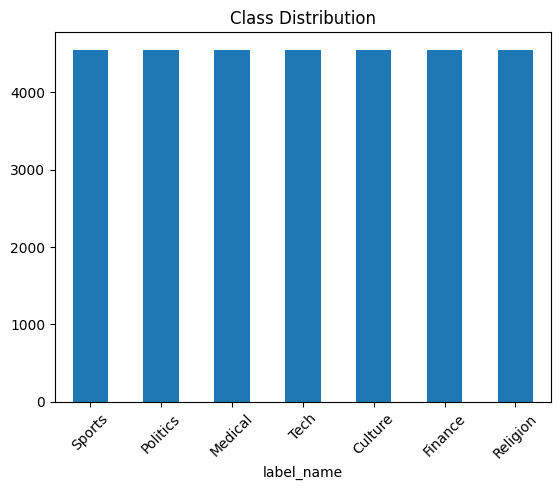

In [6]:

# ============== 6) Visualization ==============
train_c["text_len"] = train_c["text"].str.len()
train_c["text_len"].hist(bins=30)
plt.title("Text Length Distribution")
plt.show()

train_c["label_name"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()


In [7]:

# ============== 7) إعداد الليبلات ==============
labels = sorted(train_c["label_name"].unique())
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}

train_c["label"] = train_c["label_name"].map(label2id)
val_c["label"]   = val_c["label_name"].map(label2id)
test_c["label"]  = test_c["label_name"].map(label2id)

num_labels = len(label2id)
label2id


{'Culture': 0,
 'Finance': 1,
 'Medical': 2,
 'Politics': 3,
 'Religion': 4,
 'Sports': 5,
 'Tech': 6}

In [8]:

# ============== 8) تحويل إلى Dataset ==============
train_ds = Dataset.from_pandas(train_c[["text","label"]])
val_ds   = Dataset.from_pandas(val_c[["text","label"]])
test_ds  = Dataset.from_pandas(test_c[["text","label"]])


In [9]:

# ============== 9) تحميل CAMeLBERT ==============
model_name = "CAMeL-Lab/bert-base-arabic-camelbert-msa"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)


c:\Users\LENOVO\Downloads\NLP_Proj\.venv\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\LENOVO\Downloads\NLP_Proj\.venv\lib\site-packages\huggingface_hub\file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\models--CAMeL-Lab--bert-base-arabic-camelbert-msa. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer

In [10]:

# ============== 10) Tokenization ==============
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

train_tok = train_ds.map(tokenize, batched=True)
val_tok   = val_ds.map(tokenize, batched=True)
test_tok  = test_ds.map(tokenize, batched=True)

train_tok = train_tok.remove_columns(["text"])
val_tok   = val_tok.remove_columns(["text"])
test_tok  = test_tok.remove_columns(["text"])

train_tok.set_format("torch")
val_tok.set_format("torch")
test_tok.set_format("torch")


Map: 100%|██████████| 4550/4550 [00:02<00:00, 1731.78 examples/s]


In [12]:
import torch

print("CUDA available? ", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))


CUDA available?  True
CUDA device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 4060 Laptop GPU


In [16]:
print("Model device before training:", model.device)
# ============== 11) إعداد التدريب ==============
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=preds, references=labels)

args = TrainingArguments(
    output_dir=OUT_DIR,
    do_train=True,
    do_eval=True,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    fp16=True,  
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)


Model device before training: cuda:0


c:\Users\LENOVO\Downloads\NLP_Proj\.venv\lib\site-packages\accelerate\accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
c:\Users\LENOVO\Downloads\NLP_Proj\.venv\lib\site-packages\accelerate\accelerator.py:463: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [17]:

# ============== 12) Train ==============
trainer.train()


                                                 
  1%|          | 36/5973 [02:14<21:22,  4.63it/s] 

{'loss': 0.1257, 'grad_norm': 3.907818555831909, 'learning_rate': 1.833249623304872e-05, 'epoch': 0.25}


                                                 
  1%|          | 36/5973 [03:15<21:22,  4.63it/s]  

{'loss': 0.0902, 'grad_norm': 14.296014785766602, 'learning_rate': 1.6658295663820526e-05, 'epoch': 0.5}


                                                 
  1%|          | 36/5973 [04:15<21:22,  4.63it/s]  

...

                                                 
  1%|          | 36/5973 [12:14<21:22,  4.63it/s]  

{'loss': 0.0116, 'grad_norm': 0.004566714633256197, 'learning_rate': 1.5971873430436968e-06, 'epoch': 2.76}


                                                 
100%|██████████| 5973/5973 [11:55<00:00,  8.35it/s]

{'train_runtime': 715.4474, 'train_samples_per_second': 133.536, 'train_steps_per_second': 8.349, 'train_loss': 0.04832491275155722, 'epoch': 3.0}


TrainOutput(global_step=5973, training_loss=0.04832491275155722, metrics={'train_runtime': 715.4474, 'train_samples_per_second': 133.536, 'train_steps_per_second': 8.349, 'train_loss': 0.04832491275155722, 'epoch': 3.0})

In [18]:

# ============== 13) Evaluate ==============
trainer.evaluate(val_tok)


100%|██████████| 569/569 [00:15<00:00, 36.22it/s]


{'eval_loss': 0.06991969794034958,
 'eval_accuracy': 0.9867018353665238,
 'eval_runtime': 15.9368,
 'eval_samples_per_second': 570.944,
 'eval_steps_per_second': 35.704,
 'epoch': 3.0}

In [20]:
# ============== 14) Predict test-set ==============
pred = trainer.predict(test_tok)
test_c["pred"] = np.argmax(pred.predictions, axis=-1)
test_c["pred_name"] = test_c["pred"].map(id2label)

test_c.to_csv(
    r"C:\Users\LENOVO\Downloads\NLP_Proj\Data\predictions.csv",
    index=False,
    encoding="utf-8-sig"
)
test_c.head()


333it [01:01,  5.40it/s]


,text,label_name,label,pred,pred_name
0,"توفيت امرأة أجنبية بفيروس ""كورونا"" في السعودية، ليصل بذلك عدد الوفيات الناجمة عن الإصابة بهذا الفيروس الذي يتسبب في مرض متلازمة البحر المتوسط التنفسية في المملكة إلى 73 حالة .وأعلنت وزارة الصحة ال...",Politics,3,3,Politics
1,أبوظبي: «الخليج» انخفض مؤشر سوق الإمارات المالي الصادر عن هيئة الأوراق المالية والسلع خلال جلسة تداول أمس بنسبة 0.17% ليغلق على 4496.32 نقطة. وشهدت القيمة السوقية انخفاضاً بقيمة 1.21 مليار درهم لت...,Finance,1,1,Finance
2,اعتاد مجرمو الإنترنت استخدام هجمات حجب الخدمات الموزعة لانتزاع وابتزاز الأموال . ولكن هذه الهجمات باتت تستخدم على نحو متزايد كشكل من أشكال الاحتجاج على أنشطة الحكومات والشركات الكبرى . وقد شهد الر...,Tech,6,6,Tech
3,إنك تنظف أسنانك يومياً، تبدل الاطارات الخاصة بسيارتك بانتظام، وتسدد الضرائب الخاصة بك في الوقت المحدد، وتمارس التمارين الرياضية على الأقل مرتين في الأسبوع . بعبارة أخرى، لديك الكثير من العادات الج...,Tech,6,6,Tech
4,تستضيف دبي المؤتمر الرابع لطب الطوارئ الذي سيقام في فندق «انتركونتننتال فيستيفال سيتى دبي» الخميس المقبل برعاية سمو الشيخ حمدان بن راشد آل مكتوم نائب حاكم دبي وزير المالية رئيس هيئة الصحة بدبي وبد...,Medical,2,2,Medical


=== Classification Report (Test) ===
              precision    recall  f1-score   support

     Culture      0.976     0.983     0.979       650
     Finance      0.991     0.989     0.990       650
     Medical      0.988     0.995     0.992       650
    Politics      0.991     0.989     0.990       650
    Religion      0.988     0.975     0.981       650
      Sports      1.000     0.998     0.999       650
        Tech      0.985     0.986     0.985       650

    accuracy                          0.988      4550
   macro avg      0.988     0.988     0.988      4550
weighted avg      0.988     0.988     0.988      4550


Macro Precision: 0.988, Macro Recall: 0.988, Macro F1: 0.988
Micro Precision: 0.988, Micro Recall: 0.988, Micro F1: 0.988


<Figure size 800x800 with 0 Axes>

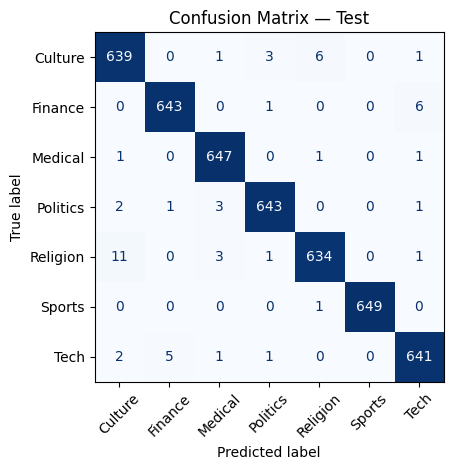

In [21]:
# ============== 15) Metrics على test-set ==============
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

# القيم الحقيقية والتوقعات كنماذج رقمية
y_true = test_c["label"].values
y_pred = test_c["pred"].values

# 1) تقرير تفصيلي لكل كلاس (precision / recall / f1 / support)
target_names = [id2label[i] for i in range(num_labels)]

print("=== Classification Report (Test) ===")
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

# 2) Precision / Recall / F1 بشكل Macro و Micro لو حابة تشوفيها صريحة
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
prec_micro, rec_micro, f1_micro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="micro", zero_division=0
)

print(f"\nMacro Precision: {prec_macro:.3f}, Macro Recall: {rec_macro:.3f}, Macro F1: {f1_macro:.3f}")
print(f"Micro Precision: {prec_micro:.3f}, Micro Recall: {rec_micro:.3f}, Micro F1: {f1_micro:.3f}")

# 3) Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(include_values=True, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Test")
plt.tight_layout()
plt.show()


In [22]:
# ============== 16) تحليل الأخطاء (Misclassifications) ==============

import numpy as np

# لو ما زال عندك متغيّر pred من trainer.predict(test_tok) نقدر نستخدمه مباشرة
# إذا مو موجود، أعيدي:
# pred = trainer.predict(test_tok)

logits = pred.predictions
probs = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)  # softmax
max_prob = probs.max(axis=1)

# نضيف معلومات زيادة لجدول التست
test_errors = test_c.copy()
test_errors["true_id"]   = test_errors["label"]
test_errors["true_name"] = test_errors["label"].map(id2label)
test_errors["pred_id"]   = test_errors["pred"]
test_errors["pred_name"] = test_errors["pred_id"].map(id2label)
test_errors["correct"]   = test_errors["true_id"] == test_errors["pred_id"]
test_errors["conf"]      = max_prob  # ثقة المودل في التوقع

# نفلتر الأخطاء فقط
misclassified = test_errors[~test_errors["correct"]].copy()
misclassified = misclassified.sort_values(by="conf", ascending=False)

print(f"عدد العينات في test: {len(test_errors)}")
print(f"عدد الأخطاء: {len(misclassified)}")

# نعرض أول 20 خطأ (أعلى ثقة مع إن الإجابة غلط)
misclassified_display = misclassified[[
    "text",
    "true_name",
    "pred_name",
    "conf"
]].head(20)

misclassified_display


عدد العينات في test: 4550
عدد الأخطاء: 54


,text,true_name,pred_name,conf
2834,في دراسة له بعنوان عصر النهضة روائياً يتتبع حنا مينة التجارب والمحاولات الروائية التي شقت طريقها نحو التغلب على جمود اللغة وقيودها بدءاً من منتصف القرن التاسع عشر على أيدي رموز مثل ابراهيم اليازجي...,Religion,Culture,0.999829
1654,نظمت جائزة زايد لطاقة المستقبل فعالية في الإمارات لإطلاق كتاب العالم الذي صنعناه لمؤلفه جوناثان بوريت، أحد أبرز الناشطين الدوليين في مجال البيئة والمدير المؤسس لمنتدى من أجل المستقبل وعضو لجنة الا...,Tech,Culture,0.999775
1230,يشهد شهر رمضان من كل عام نشاطاً مكثفاً لدور المجالس الخاصة التي تستضيف متكلمين ومحاضرين في مختلف المجالات، وخاصة الدينية والفكرية والأدبية، وهو ما يلفت الانتباه لأهمية هذه المجالس وأصالتها في تكوي...,Culture,Religion,0.999765
2837,مشروع إقامة المتاحف حتى لو أتى في البداية على نطاق محدود وبمقتنيات محدودة هو مشروع حضاري السمة، وفيه يتجسد تاريخ البلد وتاريخ الأمة، وإقامة المتحف في أي بلد أحد الأدلة على أن البلد قد بلغ شأواً مد...,Culture,Religion,0.999734
4468,كتب: علاء الدين محمود أصبحت المعارض والمهرجانات الفنية في مجالات الفنون التشكيلية، والخط العربي، والفنون البصرية الأخرى التي تقام في دولة الإمارات، مناسبة للانفتاح على الآخر، والتعرف إلى ثقافته، و...,Religion,Culture,0.999688
1554,أبوظبي رند حوشان:مع اقتراب ساعات الإفطار في إمارة أبوظبي، يسارع كثيرون للالتحاق بعائلاتهم وأسرهم للجلوس معهم على مائدة واحدة في انتظار إطلاق المدفع وأذان المغرب لتناول الإفطار، ومشاركة بعضهم بعضا ...,Religion,Medical,0.999662
4283,"يعقد مجلس وزراء الصحة لدول مجلس التعاون لدول الخليج العربية مؤتمره السادس والسبعين في مستهل دورته التاسعة والثلاثين بالكويت الثلاثاء والأربعاء المقبلين وذلك تحت شعار ""معاً لمكافحة الأمراض غير السا...",Politics,Medical,0.999610
691,قد يرى البعض، أن نماذج القدوة في عصر العولمة الثقافية، في مجتمعاتنا العربية، هي النماذج والرموز في العالم نفسها، وبالتالي هي ظاهرة عالمية في كل المجتمعات، هذا صحيح إلى حد كبير .لكن هناك مفارقة، وا...,Religion,Culture,0.999598
3313,أصدر مركز دبي للتوحد أول موسوعة شاملة حول اضطراب طيف التوحد باللغتين العربية والإنجليزية في المنطقة تحت عنوان موسوعة التوحد#171;، وتتميز باحتوائها على أدق التفاصيل والتعاريف العلمية الخاصة باضطراب...,Culture,Medical,0.999583
3033,باريس: عمار عوضاحتشدت العقول من مختلف المشارب الفكرية بمثل ما احتشدت قاعة بلدية باريس باللوحات الفنية فائقة الجمال، في القاعة التي شهدت توقيع إعلان الجمهورية الفرنسية قبل قرون، في ملتقى «الشرق وال...,Politics,Culture,0.999393


In [23]:
# ============== 17) إحصائيات سريعة عن الأخطاء لكل فئة حقيقية ==============

error_stats = (
    misclassified
    .groupby(["true_name", "pred_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_stats.head(20)


,true_name,pred_name,count
13,Religion,Culture,11
5,Finance,Tech,6
2,Culture,Religion,6
19,Tech,Finance,5
1,Culture,Politics,3
14,Religion,Medical,3
11,Politics,Medical,3
9,Politics,Culture,2
18,Tech,Culture,2
0,Culture,Medical,1


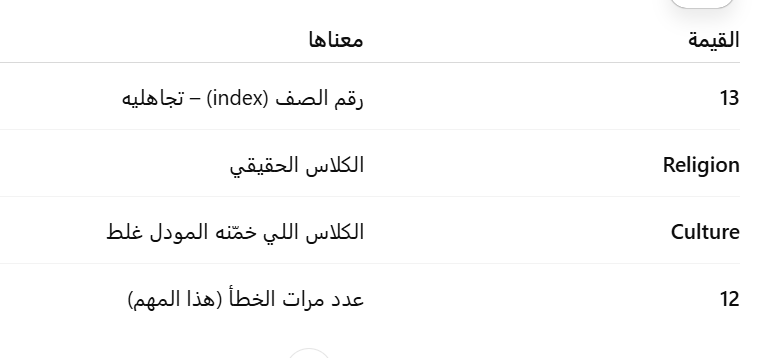

In [24]:
# =========================
# Metrics for CAMeLBERT فقط
# =========================
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_true = test_c["label"].values       # الليبل الحقيقي
y_pred = test_c["pred"].values        # توقع المودل

acc      = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_micro = f1_score(y_true, y_pred, average="micro")

print("===== CAMeLBERT on TEST =====")
print(f"Accuracy:   {acc:.3f}")
print(f"Macro F1:   {f1_macro:.3f}")
print(f"Micro F1:   {f1_micro:.3f}\n")

target_names = [id2label[i] for i in range(len(id2label))]
print("Classification report (CAMeLBERT):")
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))


===== CAMeLBERT on TEST =====
Accuracy:   0.988
Macro F1:   0.988
Micro F1:   0.988

Classification report (CAMeLBERT):
              precision    recall  f1-score   support

     Culture      0.976     0.983     0.979       650
     Finance      0.991     0.989     0.990       650
     Medical      0.988     0.995     0.992       650
    Politics      0.991     0.989     0.990       650
    Religion      0.988     0.975     0.981       650
      Sports      1.000     0.998     0.999       650
        Tech      0.985     0.986     0.985       650

    accuracy                          0.988      4550
   macro avg      0.988     0.988     0.988      4550
weighted avg      0.988     0.988     0.988      4550



In [7]:
import pandas as pd
from pathlib import Path
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

# ============= 1) تحميل الداتا النظيفة =============
train_c = pd.read_csv(r"C:\Users\LENOVO\Downloads\NLP_Proj\Data\train_clean.csv")
val_c   = pd.read_csv(r"C:\Users\LENOVO\Downloads\NLP_Proj\Data\validation_clean.csv")

# ============= 2) تجهيز الليبلات =============
labels = sorted(train_c["label_name"].unique())
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}
num_labels = len(label2id)

# ============= 3) تحويل val إلى Dataset + Tokenize =============
from datasets import Dataset
val_ds = Dataset.from_pandas(val_c[["text", "label"]])

tokenizer = AutoTokenizer.from_pretrained("CAMeL-Lab/bert-base-arabic-camelbert-msa")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

val_tok = val_ds.map(tokenize, batched=True)
val_tok = val_tok.remove_columns(["text"])
val_tok.set_format("torch")

# ============= 4) فحص كل الـ checkpoints =============
OUT_DIR = Path(r"C:\Users\LENOVO\Downloads\NLP_Proj")

checkpoints = []
for ckpt in OUT_DIR.glob("checkpoint-*"):
    try:
        step = int(ckpt.name.split("-")[-1])
        checkpoints.append((step, ckpt))
    except:
        pass

checkpoints = sorted(checkpoints, key=lambda x: x[0])

print("📂 Found checkpoints:")
for step, ckpt in checkpoints:
    print(f"  - step {step}: {ckpt}")

# ============= 5) إعداد الـ accuracy =============
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]}

results = []

for step, ckpt in checkpoints:
    print("\n" + "="*60)
    print(f"🔍 Evaluating checkpoint step {step}: {ckpt}")
    print("="*60)

    model = AutoModelForSequenceClassification.from_pretrained(
        ckpt,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    )

    eval_args = TrainingArguments(
        output_dir=str(OUT_DIR / f"eval_tmp_{step}"),
        per_device_eval_batch_size=16,
        report_to="none",
        logging_strategy="no",
        do_train=False,
        do_eval=True,
    )

    trainer_eval = Trainer(
        model=model,
        args=eval_args,
        eval_dataset=val_tok,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    eval_res = trainer_eval.evaluate()
    acc = eval_res.get("eval_accuracy") or eval_res.get("accuracy")
    print(f"   ▶ accuracy = {acc:.4f}")

    results.append((step, str(ckpt), acc))

# ============= 6) اختيار الأفضل =============
results_sorted = sorted(results, key=lambda x: x[2], reverse=True)

print("\n" + "#"*70)
print("🏆 أفضل checkpoints حسب أعلى accuracy على validation:")
for step, path, acc in results_sorted:
    print(f"step {step:5d} | acc = {acc:.4f} | {path}")

best_step, best_path, best_acc = results_sorted[0]

print("\n🎯 أفضل checkpoint فعليًا:")
print(f"→ step: {best_step}")
print(f"→ accuracy: {best_acc:.4f}")
print(f"→ path: {best_path}")


c:\Users\LENOVO\Downloads\NLP_Proj\.venv\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 9099/9099 [00:03<00:00, 2379.96 examples/s]


📂 Found checkpoints:
  - step 500: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-500
  - step 1000: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-1000
  - step 1500: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-1500
  - step 2000: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-2000
  - step 2500: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-2500
  - step 3000: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-3000
  - step 3500: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-3500
  - step 4000: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-4000
  - step 4500: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-4500
  - step 5000: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-5000
  - step 5500: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-5500

🔍 Evaluating checkpoint step 500: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-500


c:\Users\LENOVO\Downloads\NLP_Proj\.venv\lib\site-packages\accelerate\accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
100%|██████████| 569/569 [00:43<00:00, 13.13it/s]


   ▶ accuracy = 0.9743

🔍 Evaluating checkpoint step 1000: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-1000


c:\Users\LENOVO\Downloads\NLP_Proj\.venv\lib\site-packages\accelerate\accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
100%|██████████| 569/569 [00:44<00:00, 12.88it/s]


...

   ▶ accuracy = 0.9858

🔍 Evaluating checkpoint step 5000: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-5000


c:\Users\LENOVO\Downloads\NLP_Proj\.venv\lib\site-packages\accelerate\accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
100%|██████████| 569/569 [00:43<00:00, 13.00it/s]


   ▶ accuracy = 0.9862

🔍 Evaluating checkpoint step 5500: C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-5500


c:\Users\LENOVO\Downloads\NLP_Proj\.venv\lib\site-packages\accelerate\accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
100%|██████████| 569/569 [00:44<00:00, 12.78it/s]

   ▶ accuracy = 0.9865

######################################################################
🏆 أفضل checkpoints حسب أعلى accuracy على validation:
step  5500 | acc = 0.9865 | C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-5500
step  5000 | acc = 0.9862 | C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-5000
step  4000 | acc = 0.9859 | C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-4000
step  4500 | acc = 0.9858 | C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-4500
step  3500 | acc = 0.9843 | C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-3500
step  3000 | acc = 0.9840 | C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-3000
step  2000 | acc = 0.9829 | C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-2000
step  2500 | acc = 0.9829 | C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-2500
step  1500 | acc = 0.9810 | C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-1500
step  1000 | acc = 0.9780 | C:\Users\LENOVO\Downloads\NLP_Proj\checkpoint-1000
step   500 | acc = 0.9743 | C:\Users\LENOVO\Downloads\NLP_Proj